# 03. HSV Label Sweep

02번에서 crop/model input 영역을 확인했다. 이번 노트북은 **노란 차선 pseudo-label 생성**을 위한 HSV threshold 후보를 비교한다.

OpenCV는 여기서 주행 fallback이 아니라, CLRKDNet fine-tuning용 `.lines.txt`와 mask를 만들기 위한 pseudo-label 생성 도구로 사용된다.


In [1]:
from pathlib import Path
import sys, json, csv, math, random, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

PIPELINE_ROOT = Path(r"~/02_Projects/University/26-1_EmbeddedArtificialSystemOptimization/10_experiments/05_lane_finetune_dataset_pipeline")
SRC = PIPELINE_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pipeline_common as pc

pc.ensure_dirs(pc.REPORTS, pc.OUTPUTS, pc.DATASETS)
print("PIPELINE_ROOT", PIPELINE_ROOT)
print("FIELD2", pc.FIELD2)


PIPELINE_ROOT ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline
FIELD2 ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2


## 1. 샘플 이미지 구성


In [2]:
lane_manifest = pc.read_manifest(pc.MANIFESTS / "01_lane_drive_capture_manifest.csv")
scene_order = ["straight", "left_curve", "right_curve", "off_center_left", "off_center_right", "intersection_left", "intersection_right", "failure_cases"]
sample_rows = []
for scene in scene_order:
    rows = [r for r in lane_manifest if r.get("label") == scene]
    sample_rows.extend(pc.pick_evenly(rows, 4))
print("sample rows", len(sample_rows))
print(Counter := __import__('collections').Counter([r['label'] for r in sample_rows]))


sample rows 32
Counter({'straight': 4, 'left_curve': 4, 'right_curve': 4, 'off_center_left': 4, 'off_center_right': 4, 'intersection_left': 4, 'intersection_right': 4, 'failure_cases': 4})


## 2. HSV 후보 정의

각 후보는 `H,S,V`의 lower/upper 범위다. 목표는 노란선을 놓치지 않으면서 회색 도로, 초록 배경, 흰 횡단보도를 과하게 잡지 않는 것이다.


In [3]:
hsv_candidates = {
    "strict": {"lower": [22, 90, 110], "upper": [38, 255, 255], "morph_kernel": 5},
    "balanced": {"lower": [18, 60, 80], "upper": [45, 255, 255], "morph_kernel": 5},
    "wide": {"lower": [14, 40, 60], "upper": [55, 255, 255], "morph_kernel": 5},
    "bright_yellow": {"lower": [18, 80, 120], "upper": [48, 255, 255], "morph_kernel": 3},
}
print(json.dumps(hsv_candidates, indent=2, ensure_ascii=False))


{
  "strict": {
    "lower": [
      22,
      90,
      110
    ],
    "upper": [
      38,
      255,
      255
    ],
    "morph_kernel": 5
  },
  "balanced": {
    "lower": [
      18,
      60,
      80
    ],
    "upper": [
      45,
      255,
      255
    ],
    "morph_kernel": 5
  },
  "wide": {
    "lower": [
      14,
      40,
      60
    ],
    "upper": [
      55,
      255,
      255
    ],
    "morph_kernel": 5
  },
  "bright_yellow": {
    "lower": [
      18,
      80,
      120
    ],
    "upper": [
      48,
      255,
      255
    ],
    "morph_kernel": 3
  }
}


## 3. 후보별 mask ratio 통계

도로 crop 영역에서 노란 mask 비율을 계산한다. 비율이 너무 낮으면 차선을 놓쳤을 가능성이 있고, 너무 높으면 배경까지 잡았을 가능성이 있다.


In [4]:
stats = []
for name, cfg in hsv_candidates.items():
    ratios = []
    component_counts = []
    for row in sample_rows:
        rgb = pc.load_rgb(pc.pi_path_to_local(row["raw_path"]))
        crop = pc.crop_road(rgb)
        mask = pc.hsv_yellow_mask(crop, lower=tuple(cfg["lower"]), upper=tuple(cfg["upper"]), morph_kernel=cfg["morph_kernel"])
        ratio = float((mask > 0).mean())
        num_labels, labels, comp_stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), 8)
        comps = int(sum(1 for area in comp_stats[1:, cv2.CC_STAT_AREA] if area >= 30))
        ratios.append(ratio)
        component_counts.append(comps)
    good = [r for r in ratios if 0.005 <= r <= 0.18]
    stats.append({
        "candidate": name,
        "median_ratio": float(np.median(ratios)),
        "min_ratio": float(np.min(ratios)),
        "max_ratio": float(np.max(ratios)),
        "good_ratio_count": len(good),
        "median_components": float(np.median(component_counts)),
        "score": len(good) - abs(float(np.median(ratios)) - 0.04) * 30,
    })

df = pd.DataFrame(stats).sort_values("score", ascending=False)
display(df)
recommended = df.iloc[0]["candidate"]
print("recommended:", recommended)


,candidate,median_ratio,min_ratio,max_ratio,good_ratio_count,median_components,score
0,strict,0.090903,0.001939,0.123807,31,6.0,29.472911
1,balanced,0.125331,0.018909,0.177141,32,18.5,29.440073
3,bright_yellow,0.179600,0.081544,0.275015,17,15.0,12.811994
2,wide,0.445849,0.308891,0.714341,0,21.0,-12.175479


recommended: strict


## 4. 후보별 mask 시각화


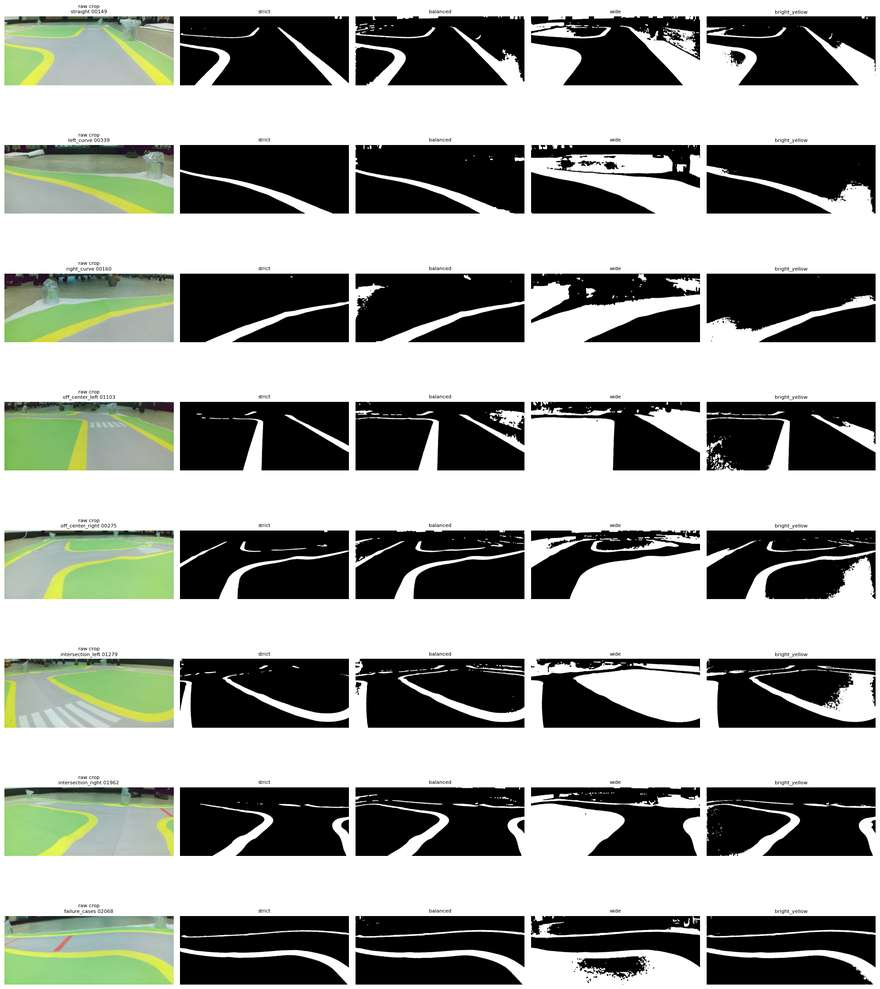

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\outputs\03_hsv_candidate_grid.png


In [5]:
preview_rows = pc.pick_evenly(sample_rows, 8)
fig, axes = plt.subplots(len(preview_rows), 1 + len(hsv_candidates), figsize=(4 * (1 + len(hsv_candidates)), 3 * len(preview_rows)))
for r_idx, row in enumerate(preview_rows):
    rgb = pc.load_rgb(pc.pi_path_to_local(row["raw_path"]))
    crop = pc.crop_road(rgb)
    axes[r_idx, 0].imshow(crop)
    axes[r_idx, 0].set_title(f"raw crop\n{row['label']} {row['frame_id']}", fontsize=8)
    axes[r_idx, 0].axis("off")
    for c_idx, (name, cfg) in enumerate(hsv_candidates.items(), start=1):
        mask = pc.hsv_yellow_mask(crop, lower=tuple(cfg["lower"]), upper=tuple(cfg["upper"]), morph_kernel=cfg["morph_kernel"])
        axes[r_idx, c_idx].imshow(mask, cmap="gray")
        axes[r_idx, c_idx].set_title(name, fontsize=8)
        axes[r_idx, c_idx].axis("off")
plt.tight_layout()
out_path = pc.OUTPUTS / "03_hsv_candidate_grid.png"
fig.savefig(pc.windows_long_path(out_path), dpi=130)
plt.show()
print(out_path)


## 5. 추천 HSV config 저장


In [6]:
best = hsv_candidates[recommended]
config = {
    "name": "field2_builder_v1_hsv",
    "paths": {
        "field2_root": str(pc.FIELD2),
        "raw_lane_root": str(pc.RAW / "01_lane_drive_capture"),
        "output_root": str(pc.DATASETS / "map_culane_field2_pseudo_v2_preview"),
    },
    "camera": pc.geometry_dict(),
    "hsv": best,
    "hsv_candidates": hsv_candidates,
    "hsv_sweep_stats": stats,
    "seed": 0,
}
config_path = pc.PIPELINE_ROOT / "configs" / "field2_builder_v1_hsv.json"
pc.write_json(config_path, config)
pc.write_json(pc.REPORTS / "03_hsv_sweep_report.json", {"recommended": recommended, "stats": stats, "figure": str(out_path)})
print(config_path)
print(json.dumps(best, indent=2, ensure_ascii=False))


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\05_lane_finetune_dataset_pipeline\configs\field2_builder_v1_hsv.json
{
  "lower": [
    22,
    90,
    110
  ],
  "upper": [
    38,
    255,
    255
  ],
  "morph_kernel": 5
}


## 6. 03번 노트북 실행 결과 정리

이번 노트북에서는 `strict`, `balanced`, `wide`, `bright_yellow` 네 가지 HSV 후보를 비교함. 샘플 기준 결과는 `strict`가 최종 추천으로 선택됨. `strict`의 mask ratio 중앙값은 약 `0.0909`, good ratio count는 `31`이었고, score는 `29.47`로 가장 높았음. `balanced`는 good ratio count가 `32`로 하나 더 많았지만 median component 수가 더 많고 mask가 조금 더 넓게 잡히는 경향이 있어 score가 `29.44`로 근소하게 밀림. `wide`는 median ratio가 약 `0.4458`로 너무 넓어 배경까지 과하게 잡는 후보로 판단됨.

추천 HSV 값은 `lower=[22, 90, 110]`, `upper=[38, 255, 255]`, `morph_kernel=5`임. 이 값은 노란 차선을 비교적 보수적으로 잡는 쪽이라, 이후 pairing 단계에서 노란선 아닌 영역이 lane point로 들어갈 위험을 줄이는 장점이 있음. 다만 보수적인 값이므로 어두운/반사/흐린 프레임 일부는 놓칠 수 있고, 이 부분은 `needs_review`나 후속 sweep에서 다룰 대상임.

결과 config는 `configs/field2_builder_v1_hsv.json`으로 저장했고, 후보별 mask 비교 이미지는 `outputs/03_hsv_candidate_grid.png`에 저장됨. 다음 단계에서는 이 HSV mask에서 ego-lane 좌우 선을 어떻게 point sequence로 뽑을지 결정해야 함.